Purification and Characterization of Progenitor and Mature Human Astrocytes Reveals Transcriptional and Functional Differences with Mouse
* Data: https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE73721

# Import packages

In [1]:
import os
import pandas as pd

from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats

import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import gseapy as gp

# Download data

In [2]:
url = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE73nnn/GSE73721/suppl/GSE73721_Human_and_mouse_table.csv.gz"
# Data is GSE73721
# GSE73nnn because GEO masks the last 3 digits
# suppl contains all the supplementary files
# Open https://ftp.ncbi.nlm.nih.gov/geo/series/GSE73nnn/GSE73721/suppl/ and you can find GSE73721_Human_and_mouse_table.csv.gz

direct_input = 'input/j.neuron.2015.11.013'
direct_output = 'output/j.neuron.2015.11.013'

for direct in [direct_input, direct_output]:
    os.makedirs(direct, exist_ok=True)

In [3]:
df = pd.read_csv(url) # Standard way of reading the GEO data
df.shape # Every col is a sample and every row is a gene
# Every cell value is the number of sequencing reads/fragments/UMIs mapped to a gene

(15041, 46)

In [4]:
df.columns

Index(['Gene', '59yo tumor periphery astro', '59yo tumor core astro',
       '64yo tumor core astro', '65yo tumor core astro',
       '21yo Hippocampus astro', '22yo Hippocampus astro',
       '53yo A Hippocampus astro', '53yo B Hippocampus astro',
       'Fetal ctx 1 astro', 'Fetal ctx 2 astro', 'Fetal ctx 3 astro',
       'Fetal ctx 4 astro', 'Fetal ctx 5 astro', 'Fetal ctx 6 astro',
       '8yo ctx astro', '13yo ctx astro', '16yo ctx astro', '21yo ctx astro',
       '22yo ctx astro', '35yo ctx astro', '47yo ctx astro', '51yo ctx astro',
       '53yo ctx astro', '60yo ctx astro', '63yo ctx 1 astro',
       '63yo ctx 2 astro', '25yo ctx neuron', '22yo ctx oligo',
       '63yo ctx A oligo', '63yo ctx B oligo ', '47yo ctx oligo',
       '63yo ctx 3 oligo', '45yo ctx myeloid', '51yo ctx myeloid',
       '63 yo ctx myeloid', '47 yo ctx endo', '13yo ctx endo',
       '45yo whole cortex', '63yo whole cortex', '25yo whole cortex',
       '53yo whole cortex', 'Mouse 1 month astro', 'Mouse 4 m

In [5]:
df['Gene'].head()

0     Aamp
1     Abat
2    Abca1
3    Abca2
4    Abcc5
Name: Gene, dtype: object

# Build sample groups

In [6]:
# Samples that we're interested in for GBM/tumor astrocytes vs normal adult cortical astrocytes
normal_cols = [
    # I took out the non-adult ones to avoid convolution from developmental factors
    # "8yo ctx astro",
    # "13yo ctx astro",
    # "16yo ctx astro",
    "21yo ctx astro",
    "22yo ctx astro",
    "35yo ctx astro",
    "47yo ctx astro",
    "51yo ctx astro",
    "53yo ctx astro",
    "60yo ctx astro",
    "63yo ctx 1 astro",
    "63yo ctx 2 astro"
]

tumor_cols = [
    "59yo tumor periphery astro",
    "59yo tumor core astro",
    "64yo tumor core astro",
    "65yo tumor core astro"
]

# Create count matrix

In [7]:
all_samples = normal_cols + tumor_cols
gene_col = 'Gene' # This is the col title for the col that contains all the gene names

needed_col_list = [gene_col] + all_samples
needed_col_list

['Gene',
 '21yo ctx astro',
 '22yo ctx astro',
 '35yo ctx astro',
 '47yo ctx astro',
 '51yo ctx astro',
 '53yo ctx astro',
 '60yo ctx astro',
 '63yo ctx 1 astro',
 '63yo ctx 2 astro',
 '59yo tumor periphery astro',
 '59yo tumor core astro',
 '64yo tumor core astro',
 '65yo tumor core astro']

In [8]:
counts = df[needed_col_list].copy() # Select all col inside needed_col_list from the df
counts.head()

,Gene,21yo ctx astro,22yo ctx astro,35yo ctx astro,47yo ctx astro,51yo ctx astro,53yo ctx astro,60yo ctx astro,63yo ctx 1 astro,63yo ctx 2 astro,59yo tumor periphery astro,59yo tumor core astro,64yo tumor core astro,65yo tumor core astro
0,Aamp,0.9,2.8,2.4,2.2,2.1,0.7,2.2,2.3,2.1,0.1,1.1,0.7,1.5
1,Abat,35.6,25.1,21.2,18.5,28.2,18.0,15.2,20.3,19.4,11.0,17.2,12.3,37.0
2,Abca1,17.2,8.4,21.8,5.3,10.1,12.8,10.0,7.1,9.5,2.1,35.2,11.2,27.5
3,Abca2,0.6,0.3,0.9,0.1,0.1,0.7,0.1,0.1,0.1,0.5,0.6,0.6,0.3
4,Abcc5,1.7,0.7,3.4,1.0,3.7,2.5,1.8,0.5,1.0,2.1,3.2,2.3,5.7


## counts df filtering

In [9]:
print(f'Before removing NaN rows, the count table has {counts.shape[0]} rows')

counts = counts.dropna() # Remove rows with NaN values, aka missing values. DEseq2 can't handle NaN values

print(f'After removing NaN rows, the count table has {counts.shape[0]} rows')

Before removing NaN rows, the count table has 15041 rows
After removing NaN rows, the count table has 15041 rows


In [10]:
print(f'Before merging duplicated gene rows, the count table has {counts.shape[0]} rows')

counts = counts.groupby(gene_col).sum() # Sometimes GEO tables contain duplicated gene symbols. This line merges duplicated gene rows

print(f'After merging duplicated gene rows, the count table has {counts.shape[0]} rows')

Before merging duplicated gene rows, the count table has 15041 rows
After merging duplicated gene rows, the count table has 15041 rows


In [11]:
print(f'Before removing almost never expressed genes, the count table has {counts.shape[0]} rows')

keep = counts.sum(axis=1) >= 10 # Remove genes with extremely low overall counts. Lower than 10 total counts across all sample is regarded as almost never expressed genes here
counts = counts.loc[keep, :]

print(f'After removing almost never expressed genes, the count table has {counts.shape[0]} rows')

Before removing almost never expressed genes, the count table has 15041 rows
After removing almost never expressed genes, the count table has 8038 rows


In [12]:
counts = counts.astype(int) # Converts values to integers because DEseq2 expect integers
counts.head()

,21yo ctx astro,22yo ctx astro,35yo ctx astro,47yo ctx astro,51yo ctx astro,53yo ctx astro,60yo ctx astro,63yo ctx 1 astro,63yo ctx 2 astro,59yo tumor periphery astro,59yo tumor core astro,64yo tumor core astro,65yo tumor core astro
Gene,,,,,,,,,,,,,
A2ld1,1,0,2,0,1,0,1,1,1,0,1,1,1
A2m,5,19,1,15,7,2,1,3,8,0,81,10,24
Aaas,3,3,7,0,2,3,1,1,1,0,5,4,2
Aadat,13,7,11,7,10,11,8,5,6,3,4,3,4
Aagab,1,1,1,1,1,0,1,2,1,0,1,1,1


# Run differential expression

In [13]:
metadata_df = pd.DataFrame( # Create a sample annotation table
    {
        "condition": ["normal"] * len(normal_cols) + ["tumor"] * len(tumor_cols)
    },
    index=all_samples
)

metadata_df # DESeq2 expects the input metadata df to have the index col for each sample name and the 1st row to be condition

,condition
21yo ctx astro,normal
22yo ctx astro,normal
35yo ctx astro,normal
47yo ctx astro,normal
51yo ctx astro,normal
53yo ctx astro,normal
60yo ctx astro,normal
63yo ctx 1 astro,normal
63yo ctx 2 astro,normal
59yo tumor periphery astro,tumor


In [14]:
# DESeq2 expects samples x genes
counts_transposed = counts.T # Transpose the count matrix
counts_transposed.iloc[:, :5] # This displays the 1st 5 col with the full rows as a preview. Now the counts has been transposed so using counts_t.head() isn't appropriate anymore since it has tons of col

# DESeq2 expects the input counts df to have the 1st col (can have or have no col title) to be sample names and each other col to be a gene

Gene,A2ld1,A2m,Aaas,Aadat,Aagab
21yo ctx astro,1,5,3,13,1
22yo ctx astro,0,19,3,7,1
35yo ctx astro,2,1,7,11,1
47yo ctx astro,0,15,0,7,1
51yo ctx astro,1,7,2,10,1
53yo ctx astro,0,2,3,11,0
60yo ctx astro,1,1,1,8,1
63yo ctx 1 astro,1,3,1,5,2
63yo ctx 2 astro,1,8,1,6,1
59yo tumor periphery astro,0,0,0,3,0


In [15]:
inference = DefaultInference(
    n_cpus = 8 # 1 to avoid multiprocessing error, which is usually caused by one of the obj cannot be pickled
)
dds = DeseqDataSet( # Create DESeq2 analysis obj
    counts=counts_transposed,
    metadata=metadata_df,
    design="~condition", # "condition" is the col title for the col that labels what each sample is (normal or tumor) in metadata_df
    refit_cooks = True, # True to refit Cooks outliers, which is advised
    inference = inference
)

if counts_transposed.index.equals(metadata_df.index): # The row names of the input metadata df must match the row names of the input counts df

    dds.deseq2() # Fit the dispersions and LFC to the model
    # 1. Normalizes for library size
    # 2. Estimates dispersion/noise for each gene
    # 3. Fits negative binomial model because RNA-seq count data are not normally distributed
    # 4. Prepares the object for statistical testing

Fitting size factors...
... done in 0.01 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 1.83 seconds.

Fitting dispersion trend curve...
... done in 0.20 seconds.

Fitting MAP dispersions...
... done in 3.42 seconds.

Fitting LFCs...
... done in 1.98 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 75 outlier genes.

Fitting dispersions...
... done in 0.06 seconds.

Fitting MAP dispersions...
... done in 0.07 seconds.

Fitting LFCs...
... done in 0.08 seconds.



In [16]:
print(dds) # This is a AnnData class obj

AnnData object with n_obs × n_vars = 13 × 8038
    obs: 'condition', 'size_factors', 'replaceable'
    var: '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', '_LFC_converged', 'replaced', 'refitted', '_pvalue_cooks_outlier'
    uns: 'trend_coeffs', 'disp_function_type', '_squared_logres', 'prior_disp_var'
    obsm: 'design_matrix', '_mu_LFC', '_hat_diagonals'
    varm: 'LFC'
    layers: 'normed_counts', '_mu_hat', 'cooks', 'replace_cooks'


## QC on model fitting

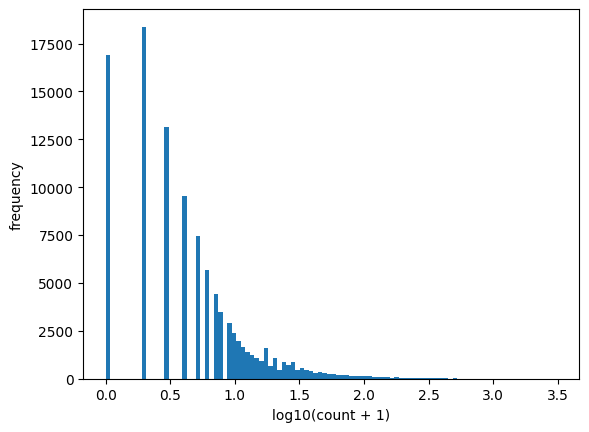

In [17]:
log_counts = np.log10(counts_transposed + 1)

plt.hist(log_counts.values.flatten(), bins=100)
plt.xlabel("log10(count + 1)")
plt.ylabel("frequency")
plt.show() # RNA-seq distribution should be highly skewed

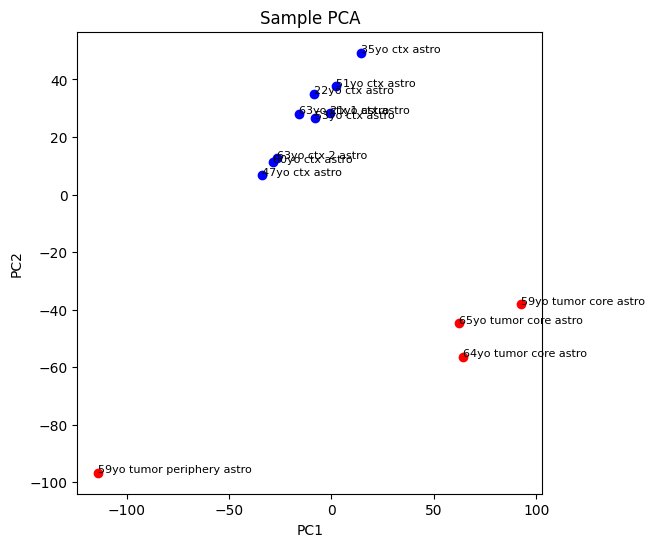

In [18]:
X = np.log2(counts_transposed + 1)

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,6))

for i, sample in enumerate(counts_transposed.index):

    condition = metadata_df.loc[sample, "condition"]

    color = "red" if condition == "tumor" else "blue"

    plt.scatter(
        pcs[i,0],
        pcs[i,1],
        color=color
    )

    plt.text(
        pcs[i,0],
        pcs[i,1],
        sample,
        fontsize=8
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Sample PCA")
plt.show() # Similar samples should be clustered together

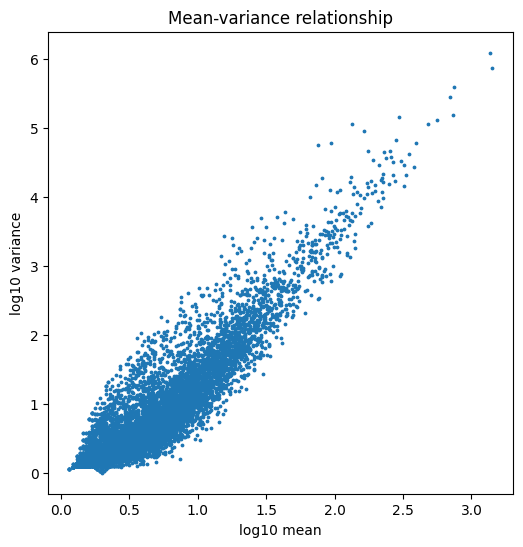

In [19]:
gene_means = counts_transposed.mean(axis=0)
gene_vars = counts_transposed.var(axis=0)

plt.figure(figsize=(6,6))

plt.scatter(
    np.log10(gene_means + 1),
    np.log10(gene_vars + 1),
    s=3
)

plt.xlabel("log10 mean")
plt.ylabel("log10 variance")
plt.title("Mean-variance relationship")
plt.show() # Because it's negative binomial, variance should increase with mean

# Extract results

In [20]:
stat_res = DeseqStats(
    dds,
    contrast=["condition", "tumor", "normal"], # Compare tumor against normal using the metadata column "condition" -> condition: tumor vs normal
    inference = inference
)

In [21]:
stat_res.summary() # Run Wald tests to compute p-values. Null hypothesis: for each gene, tumor expression is equal to normal expression

Running Wald tests...


Log2 fold change & Wald test p-value: condition tumor vs normal
         baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
Gene                                                                     
A2ld1    0.698438        0.017866  1.166136  0.015320  0.987777       NaN
A2m     11.723832        1.823847  0.912865  1.997937  0.045723  0.163983
Aaas     2.129461        0.294061  0.736989  0.399004  0.689891  0.831727
Aadat    6.764349       -1.217704  0.470141 -2.590080  0.009595  0.056483
Aagab    0.871620       -0.358474  1.085587 -0.330212  0.741240       NaN
...           ...             ...       ...       ...       ...       ...
Zxdc     2.042037        0.072675  0.685925  0.105952  0.915620  0.957116
Zyg11b   2.987793       -0.032543  0.582558 -0.055862  0.955452  0.978861
Zyx      1.032793        4.274247  2.870458  1.489047  0.136475       NaN
Zzef1    1.302765       -0.597658  0.920130 -0.649537  0.515991  0.720223
Zzz3     3.343920       -0.821286  0.608651 -1.3

... done in 1.00 seconds.



## LFC shrinkage
Raw log2 fold changes can become unrealistically huge for noisy low-count genes

Without shrinkage, DEG ranking becomes dominated by low-count noisy genes instead of robust biology.

In [22]:
print(dds.obsm['design_matrix'].columns) # Output will be the coeff for LFC shrinkage

Index(['Intercept', 'condition[T.tumor]'], dtype='object')


In [23]:
stat_res.lfc_shrink(
    coeff='condition[T.tumor]' # See the output of print(dds.obsm['design_matrix'].columns)
)

Fitting MAP LFCs...


Shrunk log2 fold change & Wald test p-value: condition[T.tumor]
         baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
Gene                                                                     
A2ld1    0.698438    7.282705e-09  0.001219  0.015320  0.987777       NaN
A2m     11.723832    2.568951e-06  0.001599  1.997937  0.045723  0.163983
Aaas     2.129461    5.923855e-07  0.001238  0.399004  0.689891  0.831727
Aadat    6.764349   -6.612035e-06  0.001181 -2.590080  0.009595  0.056483
Aagab    0.871620   -3.352124e-07  0.001210 -0.330212  0.741240       NaN
...           ...             ...       ...       ...       ...       ...
Zxdc     2.042037    1.627716e-07  0.001222  0.105952  0.915620  0.957116
Zyg11b   2.987793   -1.026446e-07  0.001217 -0.055862  0.955452  0.978861
Zyx      1.032793    6.404612e-07  0.004088  1.489047  0.136475       NaN
Zzef1    1.302765   -7.689242e-07  0.001205 -0.649537  0.515991  0.720223
Zzz3     3.343920   -2.545629e-06  0.001196 -1.3

... done in 5.82 seconds.



In [24]:
result_df = stat_res.results_df # Extract the final result table into a df
result_df.head()

# baseMean: average normalized expression. Higher means gene is strongly expressed overall
# log2FoldChange: if positive, expression is higher in tumor; if negative, expression is higher in normal
# lfcSE: Uncertainty of fold change estimate. Smaller is more reliable
# stat: Wald statistic. Higher means stronger evidence
# pvalue: raw significance. Need to be adjusted since you have tons of genes
# padj: FDR-adjusted p-value. Typical cutoff at 0.05

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Gene,,,,,,
A2ld1,0.698438,7.282705e-09,0.001219,0.015320,0.987777,NaN
A2m,11.723832,2.568951e-06,0.001599,1.997937,0.045723,0.163983
Aaas,2.129461,5.923855e-07,0.001238,0.399004,0.689891,0.831727
Aadat,6.764349,-6.612035e-06,0.001181,-2.590080,0.009595,0.056483
Aagab,0.871620,-3.352124e-07,0.001210,-0.330212,0.741240,NaN


# Result analysis

## Filter significant DEG

In [25]:
signif_df = result_df[
    (result_df["padj"] < 0.05) & # Statistically significant
    (result_df["log2FoldChange"].abs() > 1) # Biologically meaningful in effect size. This filters for gene expressions that are 2 times higher or lower in tumor. You can filter for higher differential expression
].copy()

signif_df = signif_df.sort_values('padj')

signif_df.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Gene,,,,,,
Aldh2,99.443224,-3.876705,0.302809,-13.069668,4.907957e-39,3.004651e-35
Cd44,32.201137,5.608013,0.656194,8.696763,3.414851e-18,1.045286e-14
Vim,271.900651,2.659924,0.340071,8.072037,6.913515e-16,1.410818e-12
Kdelr2,17.389724,1.852363,0.244852,7.851516,4.110381e-15,6.290937e-12
Ptpn12,17.282549,2.295883,0.320669,7.443635,9.795162e-14,1.199320e-10


In [ ]:
signif_df.to_csv(f"{direct_output}/GBM_vs_normal_astrocytes_significant_DEGs.csv")

## Separate up/down genes

In [ ]:
up = signif_df[signif_df["log2FoldChange"] > 1].sort_values("log2FoldChange", ascending=False)
down = signif_df[signif_df["log2FoldChange"] < -1].sort_values("log2FoldChange")

up.to_csv(f"{direct_output}/GBM_astrocytes_up.csv")
down.to_csv(f"{direct_output}/GBM_astrocytes_down.csv")

## Volcano plot

In [ ]:
plot_df = result_df.dropna(subset=["padj", "log2FoldChange"]).copy()

# Remove genes collapsed to near-zero LFC after LFC shrinkage for plotting only
plot_df = plot_df[plot_df["log2FoldChange"].abs() > 0.01].copy()
# This just make the volcano plot look cleaner but those gotten-rid-of genes can still be biologically/statistically valid

# Avoid infinite values if padj = 0
plot_df["padj_plot"] = plot_df["padj"].replace(0, 1e-300)
plot_df["neglog10_padj"] = -np.log10(plot_df["padj_plot"])

plot_df["direction"] = "Not significant"

plot_df.loc[
    (plot_df["padj"] < 0.05) &
    (plot_df["log2FoldChange"] > 1),
    "direction"
] = "Up in tumor"

plot_df.loc[
    (plot_df["padj"] < 0.05) &
    (plot_df["log2FoldChange"] < -1),
    "direction"
] = "Down in tumor"

# Split dataframes for coloring
plot_df_up = plot_df[
    plot_df["direction"] == "Up in tumor"
]

plot_df_down = plot_df[
    plot_df["direction"] == "Down in tumor"
]

plot_df_ns = plot_df[
    plot_df["direction"] == "Not significant"
]

plt.figure(figsize=(7, 6))

# Gray points (not significant)
plt.scatter(
    plot_df_ns["log2FoldChange"],
    plot_df_ns["neglog10_padj"],
    s=8,
    alpha=0.3,
    color="lightgray",
    label="Not significant"
)

# Red points (up in tumor)
plt.scatter(
    plot_df_up["log2FoldChange"],
    plot_df_up["neglog10_padj"],
    s=8,
    alpha=0.6,
    color="red",
    label="Up in tumor"
)

# Blue points (down in tumor)
plt.scatter(
    plot_df_down["log2FoldChange"],
    plot_df_down["neglog10_padj"],
    s=8,
    alpha=0.6,
    color="blue",
    label="Down in tumor"
)

for x in [1, -1]:
    plt.axvline(
        x,
        linestyle="--",
        color="green"
    )

plt.axhline(
    -np.log10(0.05),
    linestyle="--",
    color="green"
)

plt.xlabel("shrunk log2 fold change")
plt.ylabel("-log10(adjusted p-value)")
plt.title("GBM astrocytes vs normal cortical astrocytes")

plt.legend()

plt.show()

In [ ]:
# If gene names are in the index
plot_df["gene"] = plot_df.index

fig = px.scatter(
    plot_df,
    x="log2FoldChange",
    y="neglog10_padj",
    color='direction',
    color_discrete_map={
        "Up in tumor": "red",
        "Down in tumor": "blue",
        "Not significant": "lightgray"
    },
    hover_name="gene",
    hover_data={
        "log2FoldChange": ":.3f",
        "padj": ":.3e",
        "baseMean": ":.2f",
        "neglog10_padj": False,
        "padj_plot": False,
        "direction": True
    },
    title="GBM astrocytes vs normal cortical astrocytes",
    labels={
        "log2FoldChange": "shrunk log2 fold change",
        "neglog10_padj": "-log10(adjusted p-value)"
    },
    opacity=0.5,
    render_mode="webgl"
)

for x in [1, -1]:
    fig.add_vline(x=x, line_dash="dash", line_color="green")
fig.add_hline(y=-np.log10(0.05), line_dash="dash", line_color="green")

fig.update_traces(marker=dict(size=5))


fig.write_html(
    f"{direct_output}/interactive_volcano_plot.html",
    include_plotlyjs="cdn"
)

fig.show()

## Pick candidate genes
This is more stringent filtering

In [ ]:
candidates = signif_df[
    (signif_df["padj"] < 0.01) &
    (signif_df["log2FoldChange"].abs() > 2) &
    (signif_df["baseMean"] > 50)
    ].copy()

candidates = candidates.sort_values(
    ["padj", "log2FoldChange"],
    ascending=[True, False]
)

candidates.to_csv(f"{direct_output}/candidate_genes_for_downstream_study.csv")

## Pathway enrichment

In [ ]:
up_genes = up.index.tolist()
down_genes = down.index.tolist()

enr_up = gp.enrichr(
    gene_list=up_genes,
    gene_sets=["GO_Biological_Process_2023", "KEGG_2021_Human", "MSigDB_Hallmark_2020"],
    organism="homo sapiens"
)

enr_down = gp.enrichr(
    gene_list=down_genes,
    gene_sets=["GO_Biological_Process_2023", "KEGG_2021_Human", "MSigDB_Hallmark_2020"],
    organism="homo sapiens"
)

enr_up.results.to_csv(f"{direct_output}/enrichment_up_in_GBM.csv", index=False)
enr_down.results.to_csv(f"{direct_output}/enrichment_down_in_GBM.csv", index=False)

## Make a ranked gene list

In [ ]:
ranked = result_df.dropna(subset=["padj", "log2FoldChange"]).copy()

ranked["score"] = ranked["log2FoldChange"] * (-np.log10(ranked["padj"]))

ranked = ranked.sort_values("score", ascending=False)
ranked.head()

In [ ]:
ranked.to_csv(f"{direct_output}/ranked_genes_GBM_vs_normal.csv")